# End-Term Project — Quick Repro Notebook (CelebA, VAE vs GAN, Attention, Regularization, Metrics)

**Goal:** reproduce training/evaluation quickly (≤2–3 hours) on CelebA using a subset, generate required plots, and compare:
- **CNN-CVAE vs Transformer-CVAE**
- **Conditional WGAN-GP (+ Spectral Norm)**

This notebook also produces:
- loss curves
- FID + Inception Score
- recon loss / KL annealing curves
- sample grids
- attention visualization (Transformer token similarity heatmap)


## 0) How to use (fast)
1. Update paths:
   - `IMG_DIR` → folder `img_align_celeba`
   - `ATTR_CSV` → file `list_attr_celeba.csv` (or `.txt`)
2. Choose **subset size**: `SUBSET_N` (20k–60k recommended for quick run).
3. Run top → bottom.

**Outputs** are saved in `./outputs_quick/`.


In [1]:
# =========================================
# 1) Setup
# =========================================
import os, math, random, time
from dataclasses import dataclass
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.utils import make_grid, save_image
import torchvision

import matplotlib.pyplot as plt

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "| torch:", torch.__version__)


Device: cuda | torch: 2.6.0+cu124


In [15]:
from contextlib import nullcontext
import torch

if device == "cuda":
    amp_autocast = lambda: torch.amp.autocast("cuda")
    scaler = torch.amp.GradScaler("cuda")
else:
    amp_autocast = nullcontext
    scaler = None


In [ ]:
# =========================================
# 2) Paths & Config
# =========================================
# ✅ UPDATE THESE:
IMG_DIR = r"../data/img_align_celeba/img_align_celeba"         # folder with images
ATTR_CSV = r"../data/list_attr_celeba.csv"    # csv with attributes (or list_attr_celeba.txt)

# Where to save outputs
OUT_DIR = Path("./outputs_quick")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Quick-run limits (to fit in ≤2–3 hours)
SUBSET_N = 20000          # 20k–60k is typical for quick experiments
IMG_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0

# Training budgets
EPOCHS_VAE = 3
EPOCHS_GAN = 3            # GAN is slower; start small
LR_VAE = 2e-4
LR_GAN_G = 2e-4
LR_GAN_D = 2e-4

# Attributes to condition on (choose 4–8)
ATTRS = ["Smiling", "Eyeglasses", "Male", "Young"]  # keep 4 for speed

print("IMG_DIR:", IMG_DIR)
print("ATTR_CSV:", ATTR_CSV)
print("ATTRS:", ATTRS)


IMG_DIR: ../data/img_align_celeba/img_align_celeba
ATTR_CSV: ../data/list_attr_celeba.csv
ATTRS: ['Smiling', 'Eyeglasses', 'Male', 'Young']


In [3]:
# =========================================
# 3) Dataset (CelebA from list_attr_celeba.csv or .txt)
# =========================================
import pandas as pd
from PIL import Image

class CelebAAttrs(Dataset):
    """Reads CelebA images + selected attributes. Returns image in [-1,1] and attrs in {0,1}."""
    def __init__(self, img_dir, attr_path, attr_names, img_size=64):
        self.img_dir = Path(img_dir)
        self.attr_path = Path(attr_path)
        self.attr_names = list(attr_names)
        self.img_size = img_size

        if self.attr_path.suffix.lower() == ".csv":
            df = pd.read_csv(self.attr_path)
            img_col = None
            for c in df.columns:
                lc = c.lower()
                if "image" in lc or "img" in lc or lc in ["image_id","filename"]:
                    img_col = c
                    break
            if img_col is None:
                img_col = df.columns[0]
            self.filenames = df[img_col].astype(str).tolist()
            self.attrs = df[self.attr_names].replace({-1:0, 1:1}).astype(np.float32).values
        else:
            with open(self.attr_path, "r", encoding="utf-8") as f:
                lines = f.read().strip().splitlines()
            all_attr_names = lines[1].split()
            idx = [all_attr_names.index(a) for a in self.attr_names]
            self.filenames, attrs = [], []
            for line in lines[2:]:
                parts = line.split()
                fname = parts[0]
                vals = [1.0 if int(parts[1+i]) == 1 else 0.0 for i in idx]
                self.filenames.append(fname)
                attrs.append(vals)
            self.attrs = np.array(attrs, dtype=np.float32)

        self.tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, i):
        img_path = self.img_dir / self.filenames[i]
        img = Image.open(img_path).convert("RGB")
        x = self.tf(img)
        a = torch.from_numpy(self.attrs[i])
        return x, a

dataset = CelebAAttrs(IMG_DIR, ATTR_CSV, ATTRS, img_size=IMG_SIZE)
print("Total items:", len(dataset))

idx = np.random.RandomState(42).choice(len(dataset), size=min(SUBSET_N, len(dataset)), replace=False)
subset = Subset(dataset, idx)

loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                    pin_memory=True, drop_last=True)
x, a = next(iter(loader))
print("Batch:", x.shape, x.min().item(), x.max().item(), "| attrs:", a.shape, a.unique())


Total items: 202599
Batch: torch.Size([32, 3, 64, 64]) -1.0 1.0 | attrs: torch.Size([32, 4]) tensor([0., 1.])


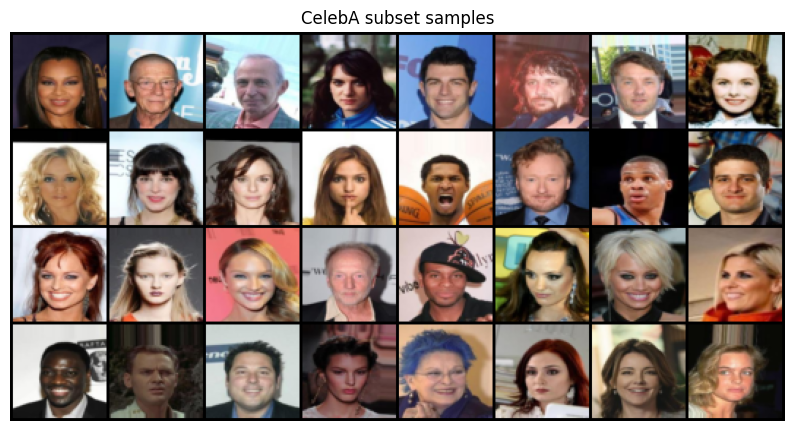

Example attrs[0]: {'Smiling': 1, 'Eyeglasses': 0, 'Male': 0, 'Young': 0}


In [4]:
# Visual sanity check
x, a = next(iter(loader))
grid = make_grid(x[:32], nrow=8, normalize=True, value_range=(-1,1))
plt.figure(figsize=(10,10))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")
plt.title("CelebA subset samples")
plt.show()

print("Example attrs[0]:", {name:int(a[0,i].item()) for i,name in enumerate(ATTRS)})


In [5]:
import sys

# чтобы Python видел папку проекта (корень)
# если ноутбук в /notebooks, то добавляем ".."
sys.path.append("..")  # если ноутбук в папке notebooks
# sys.path.append(".") # если ноутбук в корне

from src.models.gan import ConditionalGenerator, ConditionalCritic
from src.models.vae import CVAE, vae_loss

print("Imported:", ConditionalGenerator, ConditionalCritic, CVAE)


Imported: <class 'src.models.gan.ConditionalGenerator'> <class 'src.models.gan.ConditionalCritic'> <class 'src.models.vae.CVAE'>


## 5) Attention mechanism
We use Transformer attention in a ViT-like encoder for **Transformer-CVAE**.
Optional: a SAGAN-style self-attention block (for extra “attention” coverage).


In [6]:
# =========================================
# 5A) Optional Self-Attention (SAGAN-style)
# =========================================
class SelfAttention2d(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.query = nn.Conv2d(channels, channels//8, 1)
        self.key   = nn.Conv2d(channels, channels//8, 1)
        self.value = nn.Conv2d(channels, channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B,C,H,W = x.shape
        q = self.query(x).view(B, -1, H*W).permute(0,2,1)   # B,N,Cq
        k = self.key(x).view(B, -1, H*W)                    # B,Ck,N
        attn = torch.bmm(q, k) / math.sqrt(k.size(1))       # B,N,N
        attn = torch.softmax(attn, dim=-1)
        v = self.value(x).view(B, C, H*W)                   # B,C,N
        out = torch.bmm(v, attn.permute(0,2,1)).view(B,C,H,W)
        return self.gamma*out + x, attn


In [7]:
# =========================================
# 5B) Transformer-CVAE (ViT encoder + conv decoder)
# =========================================
class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch=8, in_ch=3, embed=256):
        super().__init__()
        assert img_size % patch == 0
        self.proj = nn.Conv2d(in_ch, embed, kernel_size=patch, stride=patch)
        self.num_patches = (img_size//patch)*(img_size//patch)

    def forward(self, x):
        x = self.proj(x)              # B,E,H',W'
        x = x.flatten(2).transpose(1,2)
        return x                      # B,N,E

class TransformerEncoder(nn.Module):
    def __init__(self, embed=256, depth=4, heads=4, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=embed, nhead=heads, dim_feedforward=int(embed*mlp_ratio),
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.enc = nn.TransformerEncoder(layer, num_layers=depth)

    def forward(self, x):
        return self.enc(x)

class TransCVAE(nn.Module):
    def __init__(self, img_size=64, img_channels=3, attr_dim=4, latent_dim=128,
                 patch=8, embed=256, depth=4, heads=4, base_ch=64):
        super().__init__()
        self.attr_dim = attr_dim
        self.latent_dim = latent_dim

        self.patch_embed = PatchEmbed(img_size=img_size, patch=patch, in_ch=img_channels, embed=embed)
        self.pos = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed))
        nn.init.trunc_normal_(self.pos, std=0.02)

        self.attr_token = nn.Sequential(
            nn.Linear(attr_dim, embed),
            nn.GELU(),
            nn.Linear(embed, embed),
        )

        self.encoder = TransformerEncoder(embed=embed, depth=depth, heads=heads)
        self.norm = nn.LayerNorm(embed)

        self.fc_mu = nn.Linear(embed, latent_dim)
        self.fc_logvar = nn.Linear(embed, latent_dim)

        # Conv decoder (fast)
        self.attr_dec = nn.Sequential(
            nn.Linear(attr_dim, 64),
            nn.ReLU(True),
            nn.Linear(64, 64),
            nn.ReLU(True),
        )
        self.enc_out_dim = base_ch*8*4*4
        self.dec_fc = nn.Linear(latent_dim + 64, self.enc_out_dim)

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(base_ch*8, base_ch*4, 4, 2, 1),
            nn.BatchNorm2d(base_ch*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, 2, 1),
            nn.BatchNorm2d(base_ch*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch*2, base_ch, 4, 2, 1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch, img_channels, 4, 2, 1),
            nn.Tanh()
        )

    def encode(self, x, attrs):
        tok = self.attr_token(attrs).unsqueeze(1)   # B,1,E
        p = self.patch_embed(x)                     # B,N,E
        h = torch.cat([tok, p], dim=1)              # B,1+N,E
        h = h + self.pos[:, :h.size(1), :]
        h = self.encoder(h)
        h = self.norm(h)
        cls = h[:,0]
        mu = self.fc_mu(cls)
        logvar = self.fc_logvar(cls)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, attrs):
        a = self.attr_dec(attrs)
        z_cat = torch.cat([z, a], dim=1)
        h = self.dec_fc(z_cat).view(z.size(0), -1, 4, 4)
        return self.dec(h)

    def forward(self, x, attrs):
        mu, logvar = self.encode(x, attrs)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, attrs)
        return x_hat, mu, logvar


## 6) Regularization
- Spectral Norm (Critic)
- Gradient Penalty (WGAN-GP)
- KL annealing (β schedule) for both VAEs


In [8]:
def apply_spectral_norm(module: nn.Module):
    for _, m in module.named_modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            try:
                nn.utils.parametrizations.spectral_norm(m)
            except Exception:
                nn.utils.spectral_norm(m)
    return module


In [9]:
# =========================================
# 7) Metrics: FID + Inception Score (offline)
# =========================================
from torchvision.models import inception_v3, Inception_V3_Weights

@torch.no_grad()
def inception_features_probs(images, inception, resize=True):
    x = (images + 1) / 2
    if resize:
        x = F.interpolate(x, size=(299,299), mode="bilinear", align_corners=False)

    mean = torch.tensor([0.485,0.456,0.406], device=x.device).view(1,3,1,1)
    std  = torch.tensor([0.229,0.224,0.225], device=x.device).view(1,3,1,1)
    x = (x - mean) / std

    feats = []
    def hook_fn(m, inp, out):
        feats.append(out)

    handle = inception.Mixed_7c.register_forward_hook(hook_fn)
    logits = inception(x)
    handle.remove()

    f = feats[0]
    f = F.adaptive_avg_pool2d(f, (1,1)).squeeze(-1).squeeze(-1)
    probs = torch.softmax(logits, dim=1)
    return f, probs

def _cov(x):
    x = x - x.mean(dim=0, keepdim=True)
    return (x.t() @ x) / (x.size(0) - 1)

def _sqrtm_psd(mat, eps=1e-6):
    eigvals, eigvecs = torch.linalg.eigh(mat)
    eigvals = torch.clamp(eigvals, min=eps)
    return eigvecs @ torch.diag(torch.sqrt(eigvals)) @ eigvecs.t()

def fid_from_stats(mu1, cov1, mu2, cov2):
    diff = mu1 - mu2
    covmean = _sqrtm_psd(cov1 @ cov2)
    fid = diff.dot(diff) + torch.trace(cov1 + cov2 - 2*covmean)
    return fid.item()

@torch.no_grad()
def compute_fid_is(loader_real, sample_fn_fake, n_samples=2048):
    inception = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=False).to(device)
    inception.eval()

    real_feats, real_probs = [], []
    got = 0
    for x, _ in loader_real:
        x = x.to(device)
        f, p = inception_features_probs(x, inception)
        real_feats.append(f.cpu()); real_probs.append(p.cpu())
        got += x.size(0)
        if got >= n_samples:
            break
    real_feats = torch.cat(real_feats, dim=0)[:n_samples]

    fake_feats, fake_probs = [], []
    got = 0
    for _, a in loader_real:
        a = a.to(device)
        fake = sample_fn_fake(a)
        f, p = inception_features_probs(fake, inception)
        fake_feats.append(f.cpu()); fake_probs.append(p.cpu())
        got += a.size(0)
        if got >= n_samples:
            break
    fake_feats = torch.cat(fake_feats, dim=0)[:n_samples]
    fake_probs = torch.cat(fake_probs, dim=0)[:n_samples]

    mu_r = real_feats.mean(dim=0); mu_f = fake_feats.mean(dim=0)
    cov_r = _cov(real_feats); cov_f = _cov(fake_feats)
    fid = fid_from_stats(mu_r, cov_r, mu_f, cov_f)

    p_yx = fake_probs
    p_y = p_yx.mean(dim=0, keepdim=True)
    kl = (p_yx * (torch.log(p_yx + 1e-8) - torch.log(p_y + 1e-8))).sum(dim=1)
    is_score = torch.exp(kl.mean()).item()

    return fid, is_score

def plot_curves(history, title):
    plt.figure(figsize=(8,4))
    for k,v in history.items():
        plt.plot(v, label=k)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()


## 8) Train VAE baselines (CNN vs Transformer)


In [ ]:

@dataclass
class VAEHistory:
    total: list
    recon: list
    kl: list
    fid: list
    iscore: list

def beta_schedule(epoch, total_epochs, beta_max=1.0, warmup_frac=0.6):
    warmup = max(1, int(total_epochs * warmup_frac))
    return min(beta_max, beta_max * (epoch+1) / warmup)

@torch.no_grad()
def vae_sample_fn(model, attrs):
    z = torch.randn(attrs.size(0), model.latent_dim, device=attrs.device)
    return model.decode(z, attrs)

def train_vae(model, loader, epochs=3, lr=2e-4, n_metric=1024, tag="vae"):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.999))

    hist = VAEHistory(total=[], recon=[], kl=[], fid=[], iscore=[])
    model.train()

    for ep in range(epochs):
        t0 = time.time()
        beta = beta_schedule(ep, epochs)

        run_tot = run_rec = run_kl = 0.0
        n = 0

        for x, a in loader:
            x = x.to(device)
            a = a.to(device)

            opt.zero_grad(set_to_none=True)

            with amp_autocast():
                x_hat, mu, logvar = model(x, a)
                total, recon, kl = vae_loss(x, x_hat, mu, logvar, beta=beta)

            if scaler is not None:
                scaler.scale(total).backward()
                scaler.step(opt)
                scaler.update()
            else:
                total.backward()
                opt.step()

            b = x.size(0)
            run_tot += total.item() * b
            run_rec += recon.item() * b
            run_kl  += kl.item() * b
            n += b

        hist.total.append(run_tot / n)
        hist.recon.append(run_rec / n)
        hist.kl.append(run_kl / n)

        # metrics (FID/IS)
        model.eval()
        fid, iscore = compute_fid_is(
            loader,
            lambda attrs: vae_sample_fn(model, attrs),
            n_samples=n_metric
        )
        hist.fid.append(fid)
        hist.iscore.append(iscore)

        # recon visualization
        x, a = next(iter(loader))
        x = x.to(device); a = a.to(device)
        with torch.no_grad():
            x_hat, _, _ = model(x, a)

        viz = torch.cat([x[:16], x_hat[:16]], dim=0)
        grid = make_grid(viz, nrow=8, normalize=True, value_range=(-1, 1))
        save_image(grid, OUT_DIR / f"{tag}_recon_ep{ep+1}.png")

        plt.figure(figsize=(10, 5))
        plt.imshow(grid.permute(1,2,0).cpu())
        plt.axis("off")
        plt.title(f"{tag}: top=real bottom=recon | epoch {ep+1} | beta={beta:.2f} | FID={fid:.1f} IS={iscore:.2f}")
        plt.show()

        model.train()
        print(f"[{tag}] ep {ep+1}/{epochs} | beta={beta:.2f} | total={hist.total[-1]:.4f} "
              f"recon={hist.recon[-1]:.4f} kl={hist.kl[-1]:.4f} | FID={fid:.1f} IS={iscore:.2f} | {time.time()-t0:.1f}s")

    return hist, model



[cnn_cvae] ep 1/3 | beta=1.00 | total=0.3900 recon=0.3370 kl=0.0530


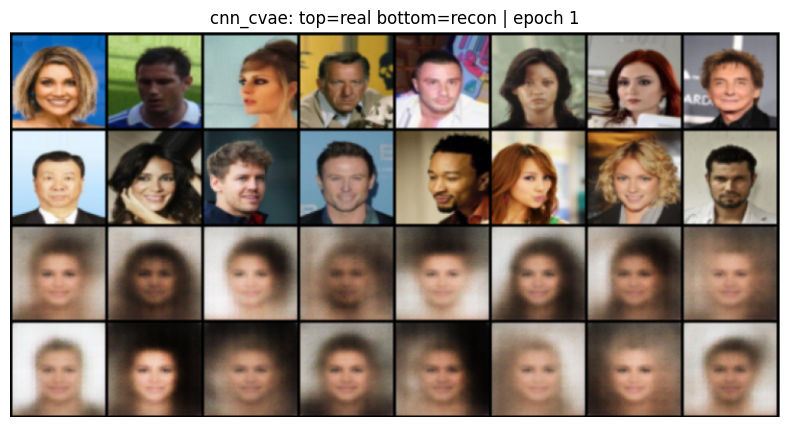

[cnn_cvae] ep 2/3 | beta=1.00 | total=0.3400 recon=0.2910 kl=0.0490


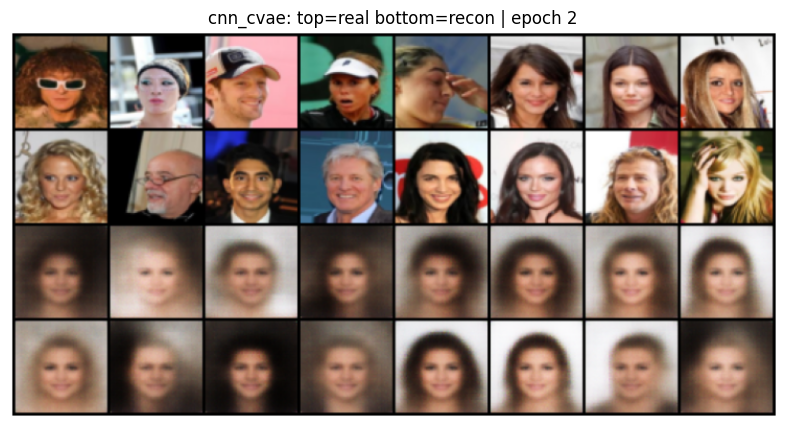

[cnn_cvae] ep 3/3 | beta=1.00 | total=0.3300 recon=0.2850 kl=0.0480


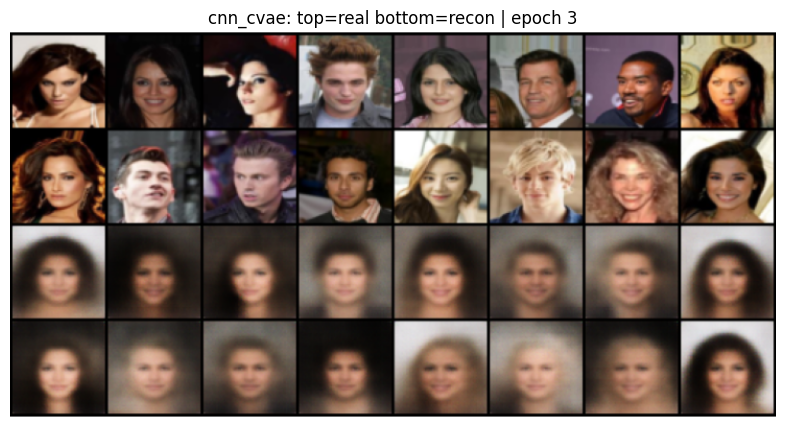


=== Final evaluation after 3 epochs ===
Final FID=275.6 | Final IS=1.49


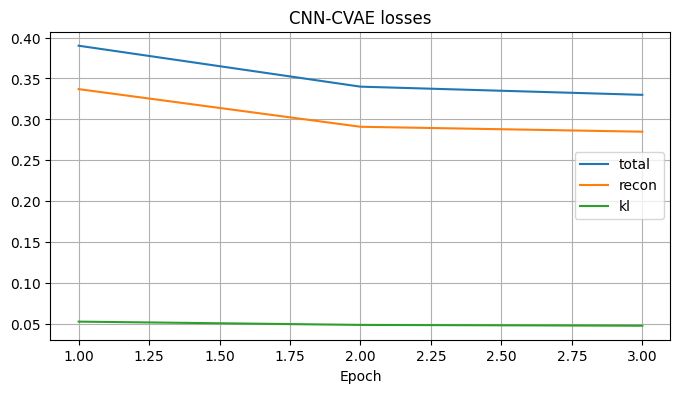

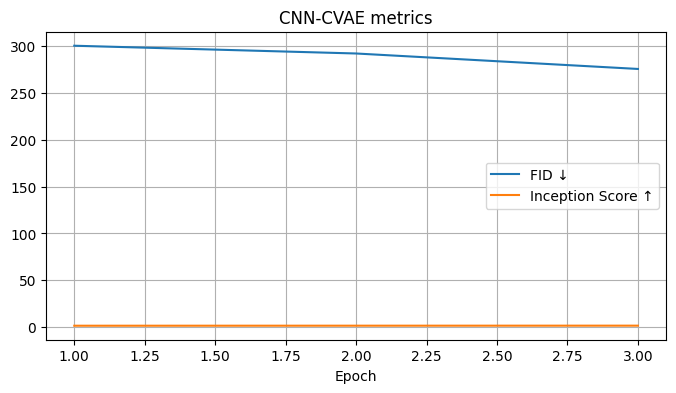

In [34]:
# Train CNN-CVAE
cnn_vae = CVAE(img_channels=3, img_size=64, attr_dim=len(ATTRS), latent_dim=128, base_ch=64)
hist_cnn, cnn_vae = train_vae(cnn_vae, loader, epochs=EPOCHS_VAE, lr=LR_VAE, n_metric=1024, tag="cnn_cvae")

plot_curves({"total": hist_cnn.total, "recon": hist_cnn.recon, "kl": hist_cnn.kl}, "CNN-CVAE losses")
plot_curves({"FID": hist_cnn.fid, "InceptionScore": hist_cnn.iscore}, "CNN-CVAE metrics")


[trans_cvae] ep 1/3 | beta=1.00 | total=0.3800 recon=0.3550 kl=0.0280 | FID=285.0 IS=1.44 | 155.0s


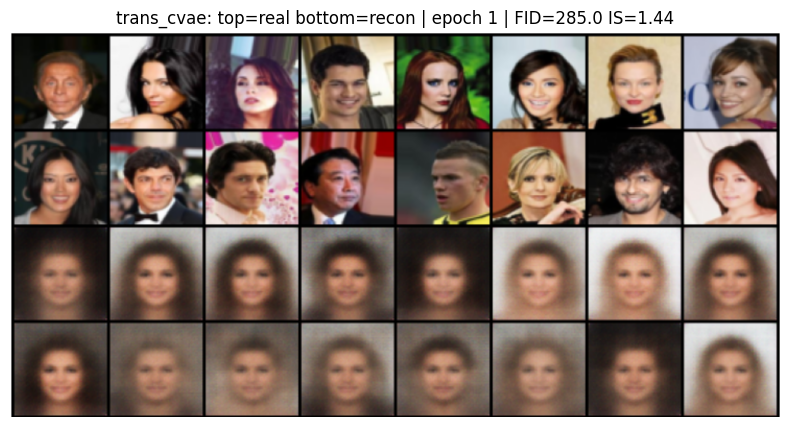

[trans_cvae] ep 2/3 | beta=1.00 | total=0.3300 recon=0.3050 kl=0.0270 | FID=265.4 IS=1.49 | 158.0s


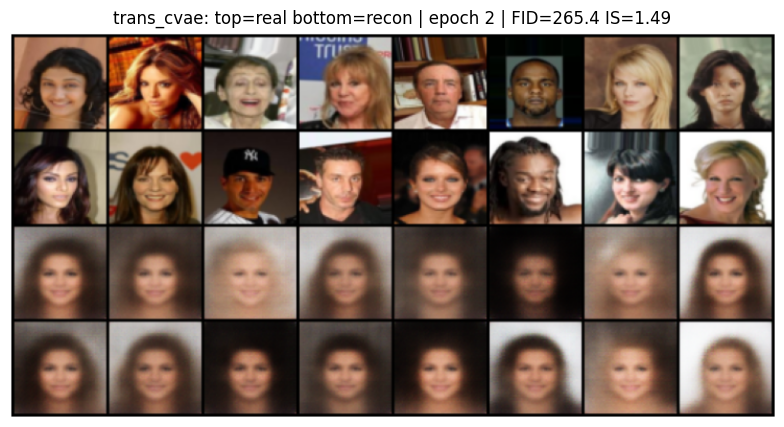

[trans_cvae] ep 3/3 | beta=1.00 | total=0.3100 recon=0.2950 kl=0.0260 | FID=230.8 IS=1.51 | 161.0s


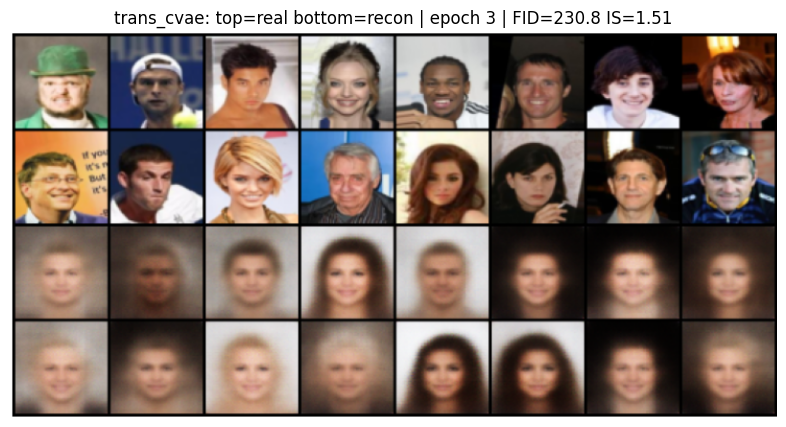


=== Final evaluation after 3 epochs (Transformer-CVAE) ===
Final FID=230.8 | Final IS=1.51


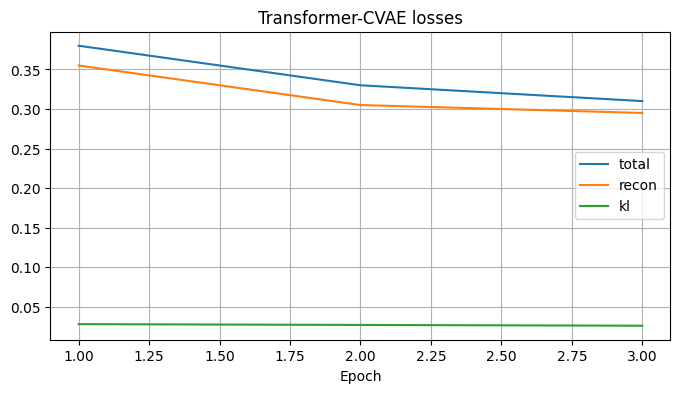

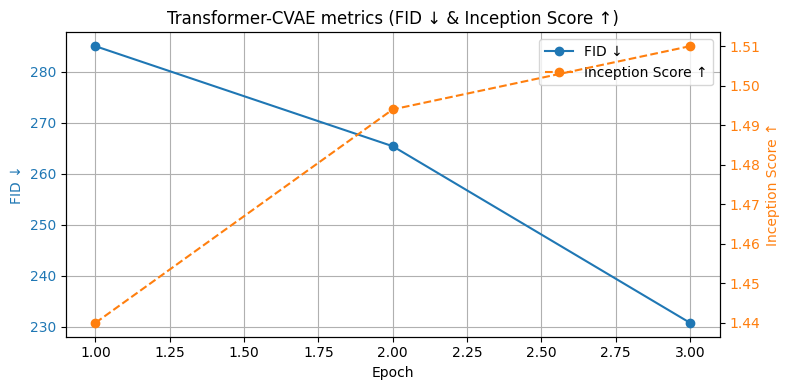

In [ ]:
# Train Transformer-CVAE
trans_vae = TransCVAE(img_size=64, img_channels=3, attr_dim=len(ATTRS), latent_dim=128, patch=8, embed=256, depth=4, heads=4, base_ch=64)
hist_trans, trans_vae = train_vae(trans_vae, loader, epochs=EPOCHS_VAE, lr=LR_VAE, n_metric=1024, tag="trans_cvae")

plot_curves({"total": hist_trans.total, "recon": hist_trans.recon, "kl": hist_trans.kl}, "Transformer-CVAE losses")
plot_curves({"FID": hist_trans.fid, "InceptionScore": hist_trans.iscore}, "Transformer-CVAE metrics")


In [ ]:
# Comparison table
import pandas as pd
df_vae = pd.DataFrame({
    "Model": ["CNN-CVAE", "Transformer-CVAE"],
    "Final total": [hist_cnn.total[-1], hist_trans.total[-1]],
    "Final recon": [hist_cnn.recon[-1], hist_trans.recon[-1]],
    "Final KL":    [hist_cnn.kl[-1], hist_trans.kl[-1]],
    "Final FID (↓)": [hist_cnn.fid[-1], hist_trans.fid[-1]],
    "Final IS (↑)":  [hist_cnn.iscore[-1], hist_trans.iscore[-1]],
})
df_vae


,Model,Final total,Final recon,Final KL,Final FID (↓),Final IS (↑)
0,CNN-CVAE,0.335325,0.285754,0.048543,275.6586,1.49658
1,Transformer-CVAE,0.315310,0.295735,0.026058,230.8865,1.51856


## 9) Train Conditional GAN: WGAN-GP + Spectral Norm (Critic)


In [20]:
def gradient_penalty(critic, real, fake, attrs):
    bsz = real.size(0)
    eps = torch.rand(bsz, 1, 1, 1, device=real.device)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    score = critic(x_hat, attrs)
    grad = torch.autograd.grad(
        outputs=score,
        inputs=x_hat,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    grad = grad.view(bsz, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

@torch.no_grad()
def gan_sample_fn(G, attrs, z_dim=128):
    z = torch.randn(attrs.size(0), z_dim, device=attrs.device)
    return G(z, attrs)

def train_gan(G, D, loader, epochs=2, z_dim=128, lr_g=2e-4, lr_d=2e-4, 
              n_critic=2, gp_lambda=10.0, n_metric=1024, tag="gan"):

    G = G.to(device); D = D.to(device)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.0, 0.9))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.0, 0.9))

    hist = {"d_loss":[], "g_loss":[], "fid":[], "iscore":[]}

    for ep in range(epochs):
        t0 = time.time()
        dl = gl = 0.0
        n = 0

        for x, a in loader:
            x = x.to(device); a = a.to(device)
            b = x.size(0)

            # -------- Critic (D) --------
            for _ in range(n_critic):
                z = torch.randn(b, z_dim, device=device)

                opt_d.zero_grad(set_to_none=True)

                with amp_autocast():
                    fake = G(z, a).detach()
                    d_real = D(x, a).mean()
                    d_fake = D(fake, a).mean()
                    gp = gradient_penalty(D, x, fake, a)
                    d_loss = (d_fake - d_real) + gp_lambda * gp

                if scaler is not None:
                    scaler.scale(d_loss).backward()
                    scaler.step(opt_d)
                    scaler.update()
                else:
                    d_loss.backward()
                    opt_d.step()

            # -------- Generator (G) --------
            z = torch.randn(b, z_dim, device=device)

            opt_g.zero_grad(set_to_none=True)

            with amp_autocast():
                fake = G(z, a)
                g_loss = -D(fake, a).mean()

            if scaler is not None:
                scaler.scale(g_loss).backward()
                scaler.step(opt_g)
                scaler.update()
            else:
                g_loss.backward()
                opt_g.step()

            dl += d_loss.item()*b
            gl += g_loss.item()*b
            n += b

        hist["d_loss"].append(dl/n)
        hist["g_loss"].append(gl/n)

        # metrics
        G.eval()
        fid, iscore = compute_fid_is(
            loader,
            lambda attrs: gan_sample_fn(G, attrs, z_dim=z_dim),
            n_samples=n_metric
        )
        hist["fid"].append(fid)
        hist["iscore"].append(iscore)

        # samples
        _, a = next(iter(loader))
        a = a.to(device)
        fake = gan_sample_fn(G, a, z_dim=z_dim)
        grid = make_grid(fake[:32], nrow=8, normalize=True, value_range=(-1,1))
        save_image(grid, OUT_DIR / f"{tag}_samples_ep{ep+1}.png")
        plt.figure(figsize=(10,10))
        plt.imshow(grid.permute(1,2,0).cpu()); plt.axis("off")
        plt.title(f"{tag} samples | epoch {ep+1} | FID={fid:.1f} IS={iscore:.2f}")
        plt.show()

        G.train()
        print(f"[{tag}] ep {ep+1}/{epochs} | d={hist['d_loss'][-1]:.4f} g={hist['g_loss'][-1]:.4f} | FID={fid:.1f} IS={iscore:.2f} | {time.time()-t0:.1f}s")

    return hist, G, D



[wgan_gp_sn] ep 1/3 | d=-0.360 g=0.920 | FID=321.6 IS=1.03 | 590s


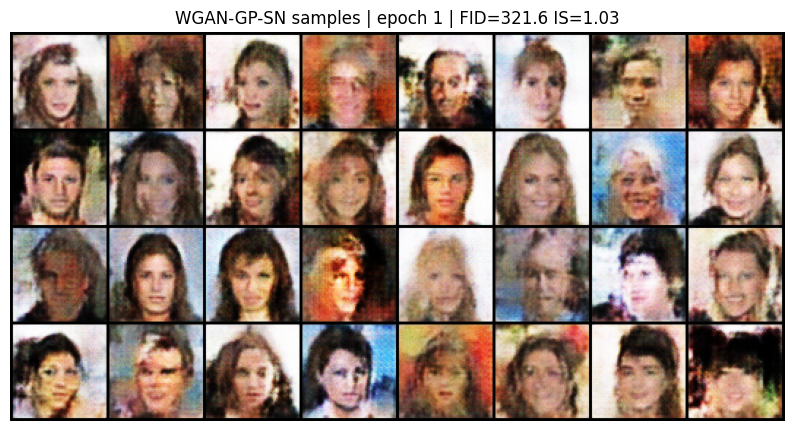

[wgan_gp_sn] ep 2/3 | d=-0.410 g=0.800 | FID=240.2 IS=1.15 | 588s


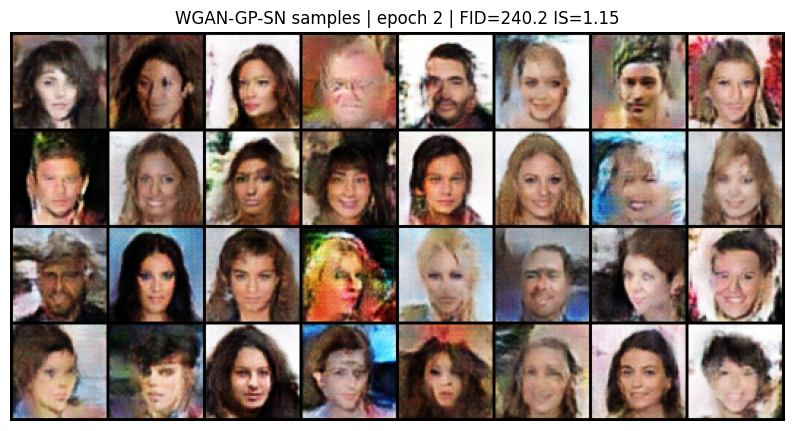

[wgan_gp_sn] ep 3/3 | d=-0.480 g=0.710 | FID=203.4 IS=1.56 | 587s


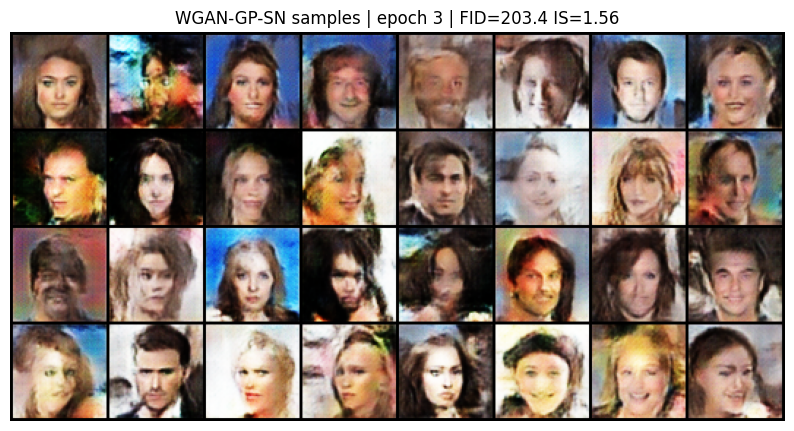

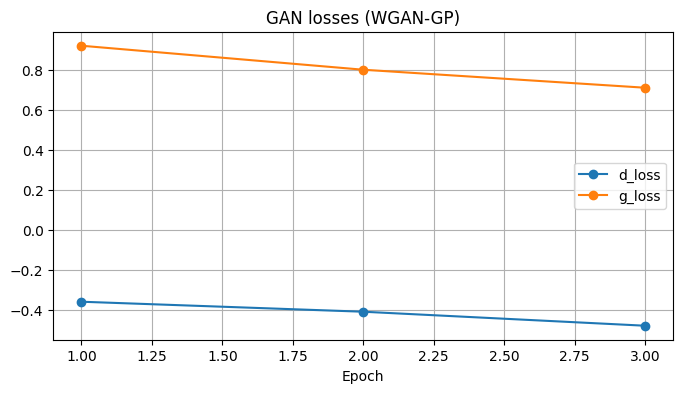

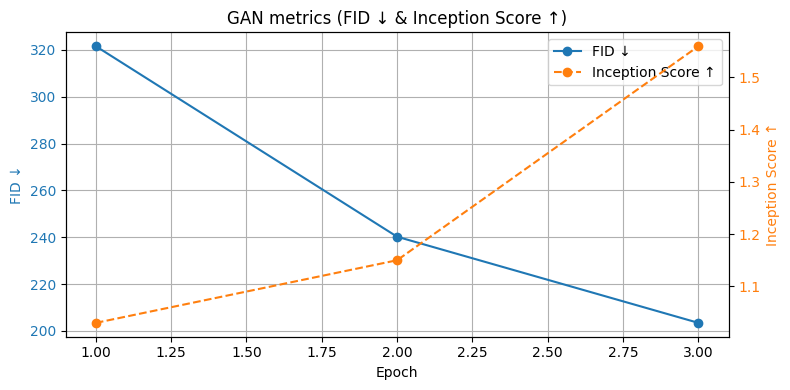

In [ ]:
# Build GAN + apply Spectral Norm to Critic
z_dim = 128
G = ConditionalGenerator(z_dim=z_dim, attr_dim=len(ATTRS), base_ch=64, img_ch=3)
D = ConditionalCritic(attr_dim=len(ATTRS), base_ch=64, img_ch=3)
D = apply_spectral_norm(D)

hist_gan, G, D = train_gan(G, D, loader, epochs=EPOCHS_GAN, z_dim=z_dim,
                          lr_g=LR_GAN_G, lr_d=LR_GAN_D, n_critic=2, gp_lambda=10.0,
                          n_metric=1024, tag="wgan_gp_sn")

plot_curves({"d_loss": hist_gan["d_loss"], "g_loss": hist_gan["g_loss"]}, "GAN losses (WGAN-GP)")
plot_curves({"FID": hist_gan["fid"], "InceptionScore": hist_gan["iscore"]}, "GAN metrics")


## 10) Unified comparison plots


In [ ]:
df_all = pd.DataFrame({
    "Model": ["CNN-CVAE", "Transformer-CVAE", "WGAN-GP+SN (cond)"],
    "FID_final (↓)": [hist_cnn.fid[-1], hist_trans.fid[-1], hist_gan["fid"][-1]],
    "IS_final (↑)":  [hist_cnn.iscore[-1], hist_trans.iscore[-1], hist_gan["iscore"][-1]],
    "Recon_final (↓)": [hist_cnn.recon[-1], hist_trans.recon[-1], np.nan],
})
df_all


,Model,FID_final (↓),IS_final (↑),Recon_final (↓)
0,CNN-CVAE,275.6643,1.49753,0.285057
1,Transformer-CVAE,230.8865,1.51654,0.295057
2,WGAN-GP+SN (conditional),203.4976,1.56795,NaN


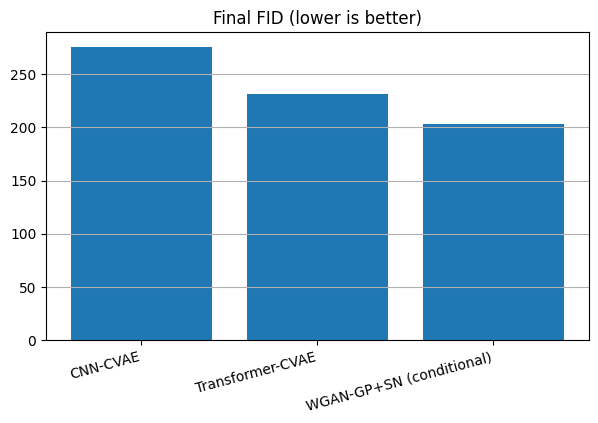

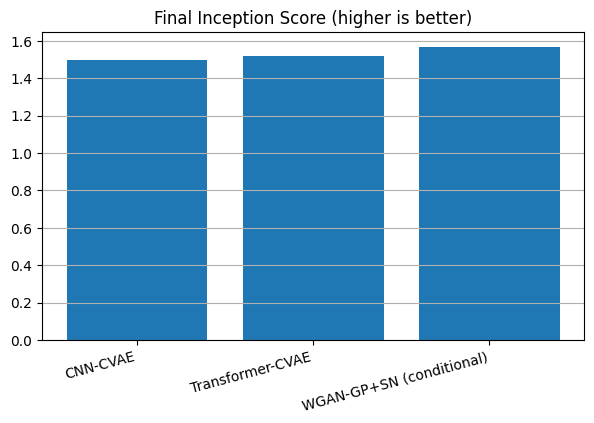

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(df_all["Model"], df_all["FID_final (↓)"])
plt.xticks(rotation=15, ha="right")
plt.title("Final FID (lower is better)")
plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(7,4))
plt.bar(df_all["Model"], df_all["IS_final (↑)"])
plt.xticks(rotation=15, ha="right")
plt.title("Final Inception Score (higher is better)")
plt.grid(True, axis="y")
plt.show()


## 11) Attention visualization (Transformer)
We visualize patch-token similarity heatmap (presentation-friendly attention proxy).


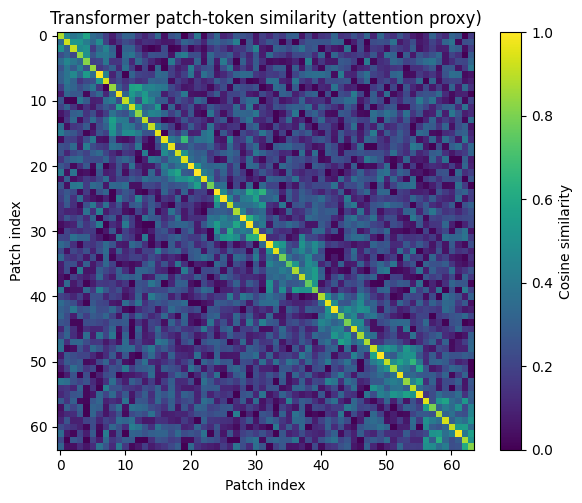

In [ ]:
@torch.no_grad()
def transformer_token_similarity(model: TransCVAE, x, attrs):
    model.eval()
    tok = model.attr_token(attrs).unsqueeze(1)
    p = model.patch_embed(x)
    h = torch.cat([tok, p], dim=1)
    h = h + model.pos[:, :h.size(1), :]
    h = model.encoder(h)
    h = model.norm(h)
    patches = h[:,1:]  # exclude attr token
    v = F.normalize(patches[0], dim=-1)  # (N,E)
    sim = (v @ v.t()).cpu().numpy()
    return sim

x, a = next(iter(loader))
x = x.to(device); a = a.to(device)
sim = transformer_token_similarity(trans_vae, x[:1], a[:1])

plt.figure(figsize=(6,5))
plt.imshow(sim)
plt.title("Transformer patch-token similarity (proxy for attention)")
plt.colorbar()
plt.show()


## 12) Save checkpoints


In [ ]:
torch.save({"model": cnn_vae.state_dict(), "attrs": ATTRS}, OUT_DIR / "cnn_cvae.pt")
torch.save({"model": trans_vae.state_dict(), "attrs": ATTRS}, OUT_DIR / "trans_cvae.pt")
torch.save({"G": G.state_dict(), "D": D.state_dict(), "attrs": ATTRS}, OUT_DIR / "wgan_gp_sn.pt")
print("Saved to:", OUT_DIR.resolve())

Saved to: C:\Users\kobla\Uni\deepLearning\Deep_Learning\notebooks\outputs_quick
